# K-Nearest Neighbors Classification
> Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

## Setup

### Environment

In [1]:
#Ignore warnings
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets

### Load the dataset iris

In [2]:
iris = datasets.load_iris()

In [3]:
df = pd.DataFrame({'Sepal length': iris.data[:,0],
                   'Sepal width': iris.data[:,1],
                   'Petal length':iris.data[:,2],
                   'Petal width':iris.data[:,3],
                   'Species':iris.target})
df.head()

,Sepal length,Sepal width,Petal length,Petal width,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df = df[df['Species'] != 0]

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 50 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal length  100 non-null    float64
 1   Sepal width   100 non-null    float64
 2   Petal length  100 non-null    float64
 3   Petal width   100 non-null    float64
 4   Species       100 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 4.7 KB


### A simple visualization

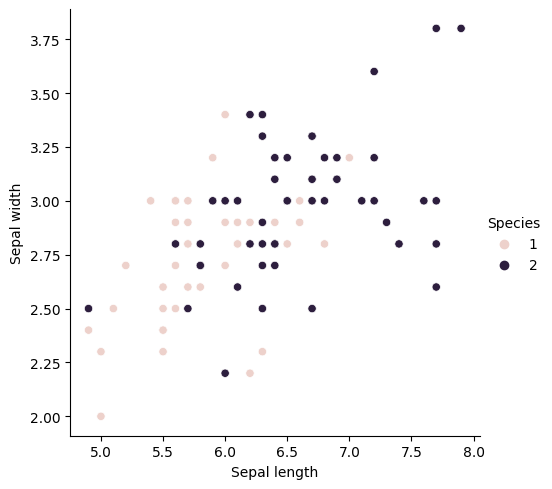

In [6]:
sns.relplot(data = df, x = 'Sepal length', y = 'Sepal width', hue = 'Species')

### Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split

X = df[df.columns[:2]]
y = df[df.columns[-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.50)

In [8]:
X_train[:5]

,Sepal length,Sepal width
110,6.5,3.2
123,6.3,2.7
55,5.7,2.8
91,6.1,3.0
51,6.4,3.2


### Scaling

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
X_train[:5]

array([[ 0.55852437,  0.86749353],
       [ 0.19347576, -0.53168958],
       [-0.90167006, -0.25185296],
       [-0.17157284,  0.30782029],
       [ 0.37600006,  0.86749353]])

## Train your model

In [11]:
k = 1

In [12]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors = k)
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [13]:
y_pred = classifier.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 2,
       1, 2, 1, 1, 1, 2, 1, 1, 2, 2, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 2, 1,
       1, 2, 2, 1, 1, 1])

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

result = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(result)
result1 = classification_report(y_test, y_pred)
print("Classification Report:",)
print (result1)
result2 = accuracy_score(y_test,y_pred)
print("Accuracy:",result2)

Confusion Matrix:
[[12  9]
 [22  7]]
Classification Report:
              precision    recall  f1-score   support

           1       0.35      0.57      0.44        21
           2       0.44      0.24      0.31        29

    accuracy                           0.38        50
   macro avg       0.40      0.41      0.37        50
weighted avg       0.40      0.38      0.36        50

Accuracy: 0.38


## Best k

In [15]:
def knn_tuning(k):
  classifier = KNeighborsClassifier(n_neighbors = k)
  classifier.fit(X_train, y_train)
  y_pred = classifier.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  return accuracy

In [16]:
knn_tuning(1)

0.38

In [17]:
knn_tuning(5)

0.54

In [18]:
knn_results = pd.DataFrame({'K':np.arange(1, len(X_train), 5)})
knn_results

,K
0,1
1,6
2,11
3,16
4,21
5,26
6,31
7,36
8,41
9,46


In [19]:
knn_results['K']

0     1
1     6
2    11
3    16
4    21
5    26
6    31
7    36
8    41
9    46
Name: K, dtype: int64

In [20]:
knn_results['Accuracy'] = knn_results['K'].apply(knn_tuning)
knn_results['Accuracy']

0    0.38
1    0.52
2    0.64
3    0.76
4    0.76
5    0.74
6    0.66
7    0.64
8    0.42
9    0.42
Name: Accuracy, dtype: float64

In [21]:
knn_results

,K,Accuracy
0,1,0.38
1,6,0.52
2,11,0.64
3,16,0.76
4,21,0.76
5,26,0.74
6,31,0.66
7,36,0.64
8,41,0.42
9,46,0.42


## Optimize weights

In [22]:
def knn_tuning_uniform(k):
  classifier = KNeighborsClassifier(n_neighbors = k, weights= 'uniform')
  classifier.fit(X_train, y_train)
  y_pred = classifier.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  return accuracy

In [23]:
def knn_tuning_distance(k):
  classifier = KNeighborsClassifier(n_neighbors = k, weights= 'distance')
  classifier.fit(X_train, y_train)
  y_pred = classifier.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  return accuracy

In [24]:
knn_results['Uniform'] = knn_results['K'].apply(knn_tuning_uniform)
knn_results['Distance'] = knn_results['K'].apply(knn_tuning_distance)
knn_results

,K,Accuracy,Uniform,Distance
0,1,0.38,0.38,0.38
1,6,0.52,0.52,0.48
2,11,0.64,0.64,0.56
3,16,0.76,0.76,0.66
4,21,0.76,0.76,0.70
5,26,0.74,0.74,0.70
6,31,0.66,0.66,0.70
7,36,0.64,0.64,0.70
8,41,0.42,0.42,0.54
9,46,0.42,0.42,0.48


## Sincerely, Mr. Eslam Fouad